In [2]:
!pip install tensorflow

In [3]:
# Importando os pacotes que serão utilizados

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.6f}'.format

In [4]:
# Carregando o arquivo CSV

df_original = pd.read_csv('teste_indicium_precificacao.csv')

In [5]:
# Verificando as primeiras linhas do DataFrame

df_original.head()

,id,nome,host_id,host_name,bairro_group,bairro,latitude,longitude,room_type,price,minimo_noites,numero_de_reviews,ultima_review,reviews_por_mes,calculado_host_listings_count,disponibilidade_365
0,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.753620,-73.983770,Entire home/apt,225,1,45,2019-05-21,0.380000,2,355
1,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.809020,-73.941900,Private room,150,3,0,NaN,NaN,1,365
2,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.685140,-73.959760,Entire home/apt,89,1,270,2019-07-05,4.640000,1,194
3,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.798510,-73.943990,Entire home/apt,80,10,9,2018-11-19,0.100000,1,0
4,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.747670,-73.975000,Entire home/apt,200,3,74,2019-06-22,0.590000,1,129


## Completude dos dados

----
1 - Faça uma análise exploratória dos dados (EDA), demonstrando as principais características entre as variáveis e apresentando algumas hipóteses de negócio relacionadas. Seja criativo!

In [6]:
# Verificando o shape dos dados, aqui podemos observar que possuimos 16 caracteríticas (variáveis) e 48894 observações.
df_original.shape

(48894, 16)

In [7]:
# Apurado do data type de cada uma das variáveis
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48894 entries, 0 to 48893
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             48894 non-null  int64  
 1   nome                           48878 non-null  object 
 2   host_id                        48894 non-null  int64  
 3   host_name                      48873 non-null  object 
 4   bairro_group                   48894 non-null  object 
 5   bairro                         48894 non-null  object 
 6   latitude                       48894 non-null  float64
 7   longitude                      48894 non-null  float64
 8   room_type                      48894 non-null  object 
 9   price                          48894 non-null  int64  
 10  minimo_noites                  48894 non-null  int64  
 11  numero_de_reviews              48894 non-null  int64  
 12  ultima_review                  38842 non-null 

In [8]:
# Verificando se há valores nulos no DataFrame. 
# Vemos que existe, mas será que isso fará diferença para a nossa abordagem?
df_original.isnull().sum()

id                                   0
nome                                16
host_id                              0
host_name                           21
bairro_group                         0
bairro                               0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimo_noites                        0
numero_de_reviews                    0
ultima_review                    10052
reviews_por_mes                  10052
calculado_host_listings_count        0
disponibilidade_365                  0
dtype: int64

In [9]:
# Medidas estatísticas principais do conjunto de dados
df_original.describe()

,id,host_id,latitude,longitude,price,minimo_noites,numero_de_reviews,reviews_por_mes,calculado_host_listings_count,disponibilidade_365
count,48894.000000,48894.000000,48894.000000,48894.000000,48894.000000,48894.000000,48894.000000,38842.000000,48894.000000,48894.000000
mean,19017532.130609,67621393.581605,40.728951,-73.952169,152.720763,7.030085,23.274758,1.373251,7.144005,112.776169
std,10982884.048876,78611176.150486,0.054529,0.046157,240.156625,20.510741,44.550991,1.680453,32.952855,131.618692
min,2595.000000,2438.000000,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9472370.750000,7822736.750000,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,19677431.500000,30795529.000000,40.723075,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,29152249.250000,107434423.000000,40.763117,-73.936273,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,36487245.000000,274321313.000000,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


## Avaliação de variáveis

In [10]:
# Converter a coluna de data para datetime (se ainda não estiver no formato correto)
df_original["data"] = pd.to_datetime(df_original["ultima_review"])

# Criar novas colunas de ano e mes
df_original["ano"] = df_original["data"].dt.year
df_original["mes"] = df_original["data"].dt.month

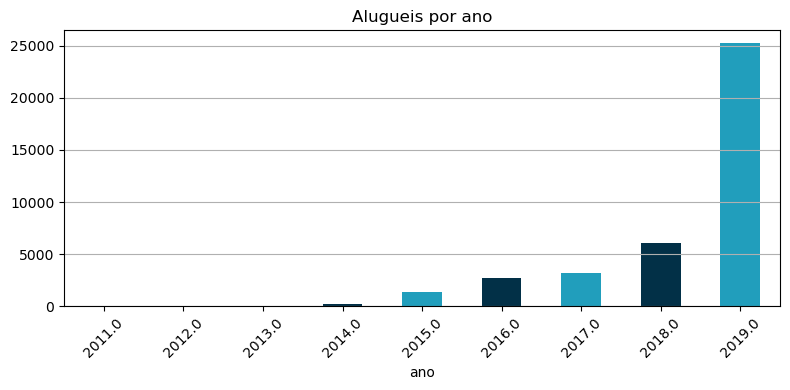

In [11]:
# Formatando o tamanho do plot
plt.rcParams["figure.figsize"] = [8, 4]
plt.rcParams["figure.autolayout"] = True

df_original.ano.value_counts().sort_index().plot(kind='bar', title='Alugueis por ano',color = ['#219ebc', '#023047'])

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

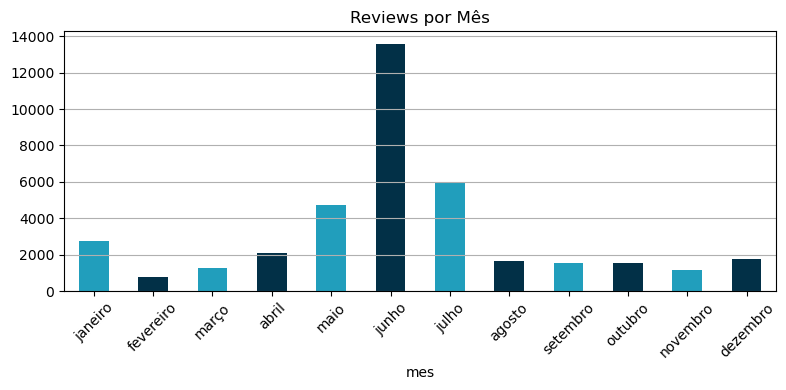

In [12]:
dic = {1: "janeiro", 2: "fevereiro", 3: "março", 4: "abril",5: "maio", 6: "junho", 7: "julho", 8: "agosto",9: "setembro", 10: "outubro", 11: "novembro", 12: "dezembro"}

# Conta os reviews por mês e ordena
mes_review = df_original.mes.value_counts().sort_index()

# Criar o gráfico de barras
ax = mes_review.plot(kind='bar', title='Reviews por Mês', color=['#219ebc', '#023047'])

# Substituir os números do eixo X pelos nomes dos meses
ax.set_xticks(range(len(mes_review)))  # Define a posição dos ticks
ax.set_xticklabels([dic[m] for m in mes_review.index], rotation=45)  # Substitui pelos nomes

plt.grid(axis='y')
plt.show()

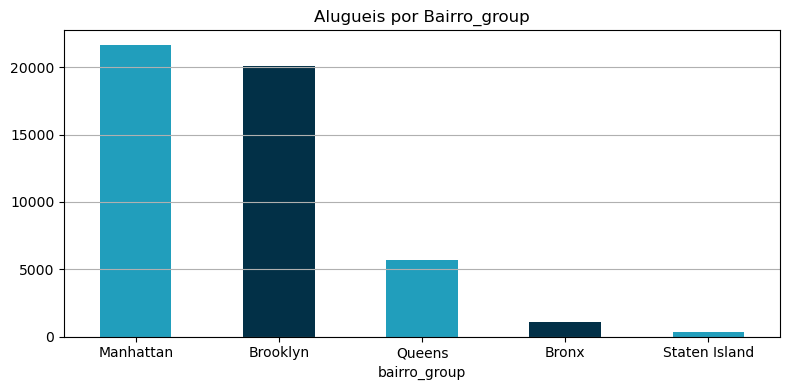

In [13]:
df_original.bairro_group.value_counts().plot(kind='bar', title='Alugueis por Bairro_group',color = ['#219ebc', '#023047'])

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

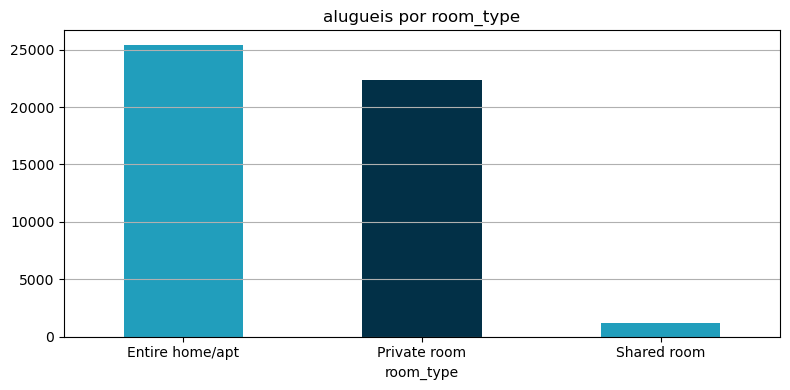

In [14]:
df_original.room_type.value_counts().plot(kind='bar', title='alugueis por room_type',color = ['#219ebc', '#023047'])

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

2 - Responda também às seguintes perguntas:

---
a - Supondo que uma pessoa esteja pensando em investir em um apartamento para alugar na plataforma, onde seria mais indicada a compra?

b - O número mínimo de noites e a disponibilidade ao longo do ano interferem no preço?

c - Existe algum padrão no texto do nome do local para lugares de mais alto valor?

a -  Analisando os gráficos passados, podemos perceber padrões de alugueis no banco de dados:

- Existe uma procura maior de alugueis no bairro de Manhattan e Brooklin

- Existe uma procura maior para alugueis do tipo Entire Home e Private room

- Podemos imaginar que existe uma procura muito maior no meio do ano

- Estimativa de crescimento de alugueis

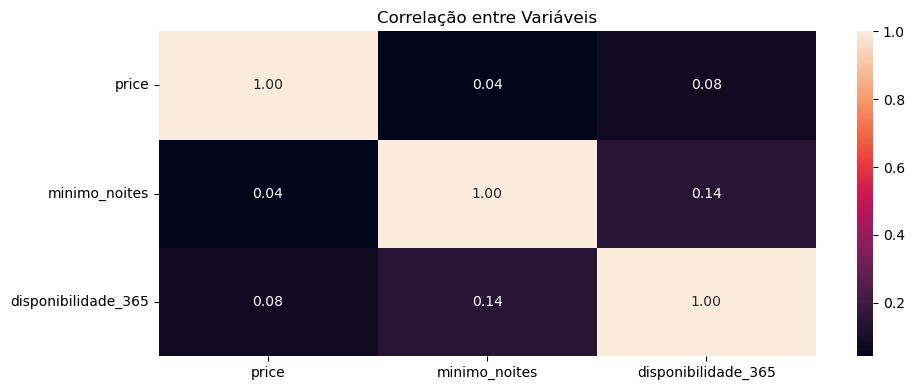

In [15]:
# Matriz de Correlação
corr_matrix = df_original[["price", "minimo_noites", "disponibilidade_365"]].corr()

# Exibir heatmap
plt.figure(figsize=(10,4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlação entre Variáveis")
plt.show()

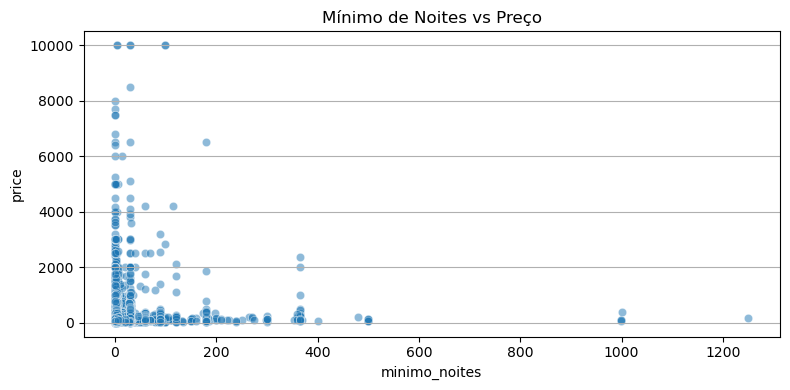

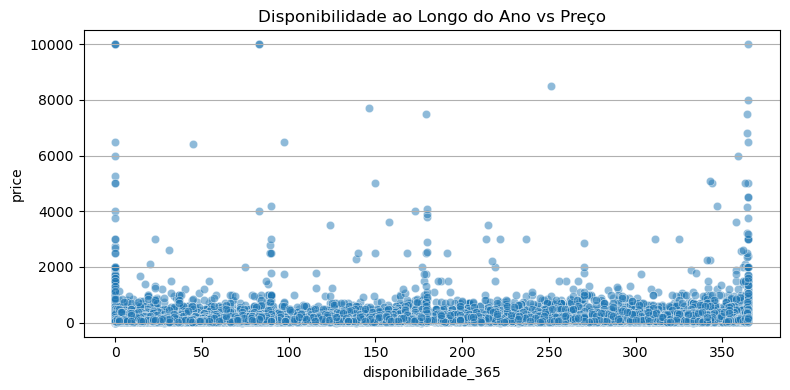

In [16]:
# Scatter plot para "mínimo de noites" vs preço
sns.scatterplot(data=df_original, x="minimo_noites", y="price", alpha=0.5)
plt.title("Mínimo de Noites vs Preço")
plt.grid(axis='y')
plt.show()

# Scatter plot para "disponibilidade ao longo do ano" vs preço
sns.scatterplot(data=df_original, x="disponibilidade_365", y="price", alpha=0.5)
plt.title("Disponibilidade ao Longo do Ano vs Preço")
plt.grid(axis='y')
plt.show()

b - O gráfico de correlação indicou pouca correlação, entre preço mínimo de noites e disponibilidade no ano. Contudo devemos lembrar que a não correlação não significa a não casualidade.

O scatter plot nos mostrou inicialmente uma relação entre preços altos e mínimo de noites; contudo, se considerarmos os outliers presentes, é muito possível que essa relação seja menor do que aparenta. Acredito que, sim, o mínimo de noites afeta o preço, mas o efeito de outras variáveis não deixa isso tão evidente.

Já o scatter plot da disponibilidade anual se mostrou contante o que é um bom indício de não casualidade entre o preço e essa variável. Ou seja, a disponibilidade anual não afeta o preço.

In [17]:
dados_precos_altos = df_original[df_original["price"] > 5000][["nome", "host_name", "bairro"]]
dados_precos_altos


,nome,host_name,bairro
3536,UWS 1BR w/backyard + block from CP,Jay And Liz,Upper West Side
3719,"SuperBowl Penthouse Loft 3,000 sqft",Omri,Little Italy
3773,SUPER BOWL Brooklyn Duplex Apt!!,Jonathan,Clinton Hill
4376,Film Location,Jessica,Clinton Hill
6529,Spanish Harlem Apt,Olson,East Harlem
9150,Furnished room in Astoria apartment,Kathrine,Astoria
12341,"Quiet, Clean, Lit @ LES & Chinatown",Amy,Lower East Side
15559,Luxury townhouse Greenwich Village,Linda,Greenwich Village
17691,Luxury 1 bedroom apt. -stunning Manhattan views,Erin,Greenpoint
29237,1-BR Lincoln Center,Jelena,Upper West Side


C - Observando os 20 alugueis mais caros do banco de dados, não percebemos um padrão geral e constante em todos. Contudo, algumas palavras que se repetem devem ser destacadas:

Luxury - 5 vezes

Manhatan - 3 vezes

SuperBowl - 2 vezes

## Tratamento dos Dados

---
3 - Explique como você faria a previsão do preço a partir dos dados. Quais variáveis e/ou suas transformações você utilizou e por quê? Qual tipo de problema estamos resolvendo (regressão, classificação)? Qual modelo melhor se aproxima dos dados e quais seus prós e contras? Qual medida de performance do modelo foi escolhida e por quê?

Primeiramente, faz-se necessária a observação das variáveis que não contribuirão para a melhora do modelo. Inicialmente, são elas:

(id, nome, host_id, host_name, última review) – essas variáveis são exclusivas ou quase exclusivas para cada aluguel. Variáveis que não possuem capacidade de generalização dentro do banco de dados podem apenas adicionar complexidade ao modelo sem melhorar os resultados.

Posteriormente, há mais duas variáveis que merecem destaque nessa decisão:

Disponibilidade anual – a decisão sobre utilizá-la ou não foi baseada na análise de um scatter plot. Calculado_host_listings_count – confesso que não compreendi essa variável com clareza, então treinei o modelo com e sem ela para avaliar os resultados.As demais variáveis foram utilizadas, principalmente devido à sua capacidade de generalização.

Trata-se de um problema de regressão, pois estamos tentando estimar a variável preço, que é numérica e não categórica. Os métodos de machine learning utilizados foram regressão linear e rede neural artificial. Apesar de ambas apresentarem erros similares, a regressão linear demonstrou um desempenho superior para essa situação, uma vez que modelos neurais requerem mais tempo de treinamento.

Por fim, as métricas de desempenho utilizadas foram o erro absoluto médio (MAE) e o erro quadrático médio (MSE), comumente empregadas em problemas de regressão.

In [18]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [19]:
# Apesar da quantidade de valores nulos, juguei que são em variáveis que não tem correlação com o preço.
df_original.isnull().sum()

id                                   0
nome                                16
host_id                              0
host_name                           21
bairro_group                         0
bairro                               0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimo_noites                        0
numero_de_reviews                    0
ultima_review                    10052
reviews_por_mes                  10052
calculado_host_listings_count        0
disponibilidade_365                  0
data                             10052
ano                              10052
mes                              10052
dtype: int64

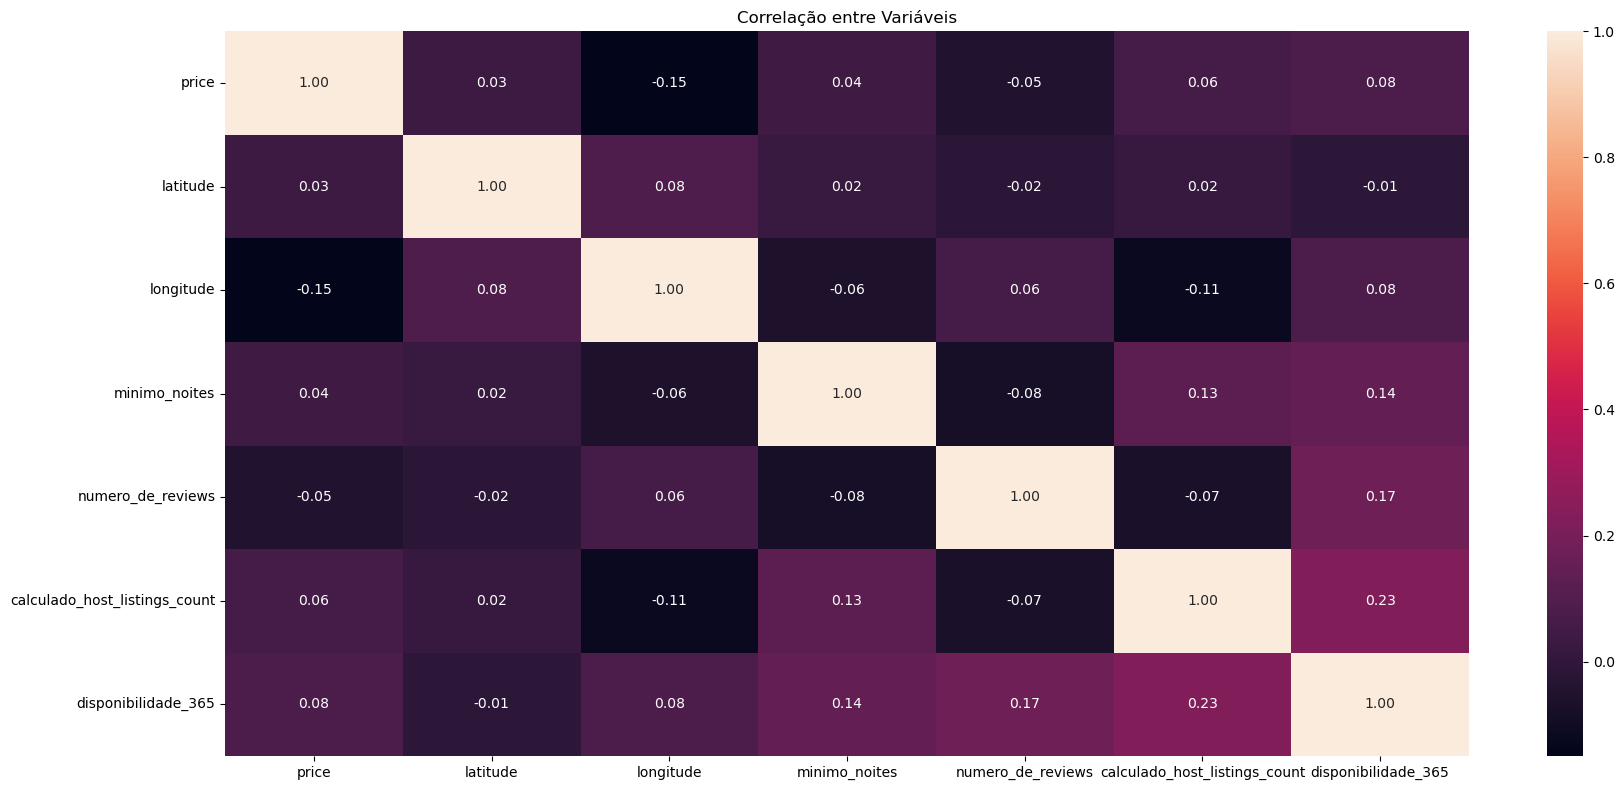

In [20]:
# matriz de correlação completa
corr_matrix = df_original[["price", "latitude", "longitude", "minimo_noites", "numero_de_reviews", "calculado_host_listings_count", "disponibilidade_365"]].corr()

# Exibir heatmap
plt.figure(figsize=(18,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlação entre Variáveis")
plt.show()

In [21]:
# Excluindo variáveis que considero irrelevantes para o modelo
df_tratado = df_original.drop(columns=["id", "nome", "host_id", "host_name", "ultima_review","reviews_por_mes", "data", "ano", "mes"])

In [22]:
# Utilizando o intervalo interquartil para identificar outliers
Q1 = df_original["minimo_noites"].quantile(0.25)
Q3 = df_original["minimo_noites"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra os dados sem outliers
df_tratado = df_tratado[(df_tratado["minimo_noites"] >= limite_inferior) & (df_tratado["minimo_noites"] <= limite_superior)]

In [23]:
Q1 = df_original["price"].quantile(0.25)
Q3 = df_original["price"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra os dados sem outliers
df_tratado = df_tratado[(df_tratado["price"] >= limite_inferior) & (df_tratado["price"] <= limite_superior)]

In [24]:
df_tratado.describe()

,latitude,longitude,price,minimo_noites,numero_de_reviews,calculado_host_listings_count,disponibilidade_365
count,39737.000000,39737.000000,39737.000000,39737.000000,39737.000000,39737.000000,39737.000000
mean,40.727575,-73.949145,119.000503,2.696203,26.377985,3.072980,97.163097
std,0.056293,0.047709,67.184941,1.863541,47.475170,19.744108,124.360620
min,40.499790,-74.244420,0.000000,1.000000,0.000000,1.000000,0.000000
25%,40.688080,-73.981040,65.000000,1.000000,1.000000,1.000000,0.000000
50%,40.720080,-73.953320,100.000000,2.000000,7.000000,1.000000,25.000000
75%,40.763260,-73.932170,155.000000,3.000000,29.000000,2.000000,179.000000
max,40.913060,-73.712990,334.000000,11.000000,629.000000,327.000000,365.000000


In [25]:
df_tratado.head()

,bairro_group,bairro,latitude,longitude,room_type,price,minimo_noites,numero_de_reviews,calculado_host_listings_count,disponibilidade_365
0,Manhattan,Midtown,40.753620,-73.983770,Entire home/apt,225,1,45,2,355
1,Manhattan,Harlem,40.809020,-73.941900,Private room,150,3,0,1,365
2,Brooklyn,Clinton Hill,40.685140,-73.959760,Entire home/apt,89,1,270,1,194
3,Manhattan,East Harlem,40.798510,-73.943990,Entire home/apt,80,10,9,1,0
4,Manhattan,Murray Hill,40.747670,-73.975000,Entire home/apt,200,3,74,1,129


In [26]:
# Usando o método de Min Max para escalonar os valores numéricos
norm = MinMaxScaler()
df_tratado[[ "latitude", "longitude", "minimo_noites", "numero_de_reviews", "disponibilidade_365",  "calculado_host_listings_count"]] = norm.fit_transform(df_tratado[[ "latitude", "longitude", "minimo_noites", "numero_de_reviews", "disponibilidade_365", "calculado_host_listings_count"]])

In [27]:
norm_price = MinMaxScaler()
df_tratado[["price"]] = norm_price.fit_transform(df_tratado[["price"]])

In [28]:
# Tratando as variáveis categóricas
df_tratado = pd.get_dummies(df_tratado, columns=["bairro_group", "room_type"], drop_first=True)

In [29]:
# Usando LabelEncoder para tratar variáveis categóricas numerosas
encoder = LabelEncoder()
df_tratado["bairro"] = encoder.fit_transform(df_tratado["bairro"])

## Criando modelo Neural

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split

In [31]:
# Separar variáveis de entrada e saída
X = df_tratado.drop(columns=["price"])  # Supondo que "preco" seja a variável alvo
y = df_tratado["price"]

In [32]:
# Separa 80% para treino e 20% para validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Criar o modelo de rede neural
model = Sequential([
    Dense(128, activation="relu", input_shape=(X.shape[1],)),  
    Dropout(0.2),  # Dropout de 20%
    
    Dense(64, activation="relu"),
    Dropout(0.2),  # Dropout de 10% na segunda camada

    Dense(64, activation="relu"),
    Dropout(0.1),  # Dropout de 10% na terceira camada
    
    Dense(32, activation="relu"),
    Dropout(0.1),  # Dropout de 10% na terceira camada

    Dense(1, activation="linear")  # Saída (regressão)
])

# Compilar o modelo
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Treinar o modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val))

c:\Users\Micael\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 9.6137 - mae: 1.2747 - val_loss: 0.0587 - val_mae: 0.1751
Epoch 2/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0958 - mae: 0.2137 - val_loss: 0.0438 - val_mae: 0.1567
Epoch 3/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0514 - mae: 0.1693 - val_loss: 0.0400 - val_mae: 0.1577
Epoch 4/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0436 - mae: 0.1642 - val_loss: 0.0413 - val_mae: 0.1575
Epoch 5/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0403 - mae: 0.1603 - val_loss: 0.0386 - val_mae: 0.1558
Epoch 6/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0380 - mae: 0.1544 - val_loss: 0.0294 - val_mae: 0.1330
Epoch 7/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0333 - mae: 0.1408 - val_loss: 0.0263 - val_mae: 0.1242
Epoch 8/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0313 - mae: 0.1347 - val_loss: 0.0280 - val_mae: 0.1210
Epoch 9/50
994/994 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

## Previsão teste

In [34]:
teste = {'id': [259],
 'nome': ['Skylit Midtown Castle'],
 'host_id': [2845],
 'host_name': ['Jennifer'],
 'bairro': ['Midtown'],
 'latitude': [40.75362],
 'longitude': [-73.98377],
 'minimo_noites': [1],
 'numero_de_reviews': [45],
 'ultima_review': ['2019-05-21'],
 'reviews_por_mes': [0.38],
 'calculado_host_listings_count': [2],
 'disponibilidade_365': [355],
 'bairro_group_Brooklyn': False,
 'bairro_group_Manhattan': True,
 'bairro_group_Queens': False,
 'bairro_group_Staten Island': False,
 'room_type_Private room': False,
 'room_type_Shared room': False}


In [35]:
teste = pd.DataFrame(teste)

In [36]:
teste.head()

,id,nome,host_id,host_name,bairro,latitude,longitude,minimo_noites,numero_de_reviews,ultima_review,reviews_por_mes,calculado_host_listings_count,disponibilidade_365,bairro_group_Brooklyn,bairro_group_Manhattan,bairro_group_Queens,bairro_group_Staten Island,room_type_Private room,room_type_Shared room
0,259,Skylit Midtown Castle,2845,Jennifer,Midtown,40.753620,-73.983770,1,45,2019-05-21,0.380000,2,355,False,True,False,False,False,False


In [37]:
teste = teste.drop(columns=["id", "nome", "host_id", "host_name", "ultima_review","reviews_por_mes"])

In [38]:
teste[[ "latitude", "longitude", "minimo_noites", "numero_de_reviews", "disponibilidade_365", "calculado_host_listings_count"]] = norm.transform(teste[[ "latitude", "longitude", "minimo_noites", "numero_de_reviews", "disponibilidade_365", "calculado_host_listings_count"]])

In [39]:
teste["bairro"] = encoder.transform(teste["bairro"])

In [40]:
Preco_aluguel = model.predict(teste)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [41]:
Preco_aluguel = norm_price.inverse_transform(Preco_aluguel.reshape(-1,1))

In [42]:
print(f'O preço estimado é de ${Preco_aluguel[0][0]:.2f}')

O preço estimado é de $200.60


## Regressão linear

In [43]:
# Para implementação da regressão linear
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [44]:
mapeamento = {True: 1, False: 0}

In [45]:
df_rl = df_tratado.replace(mapeamento)

C:\Users\Micael\AppData\Local\Temp\ipykernel_15920\1106882684.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_rl = df_tratado.replace(mapeamento)


In [46]:
df_rl.head()

,bairro,latitude,longitude,price,minimo_noites,numero_de_reviews,calculado_host_listings_count,disponibilidade_365,bairro_group_Brooklyn,bairro_group_Manhattan,bairro_group_Queens,bairro_group_Staten Island,room_type_Private room,room_type_Shared room
0,126,0.614199,0.490469,0.673653,0.000000,0.071542,0.003067,0.972603,0,1,0,0,0,0
1,93,0.748252,0.569257,0.449102,0.200000,0.000000,0.000000,1.000000,0,1,0,0,1,0
2,41,0.448496,0.535649,0.266467,0.000000,0.429253,0.000000,0.531507,1,0,0,0,0,0
3,61,0.722820,0.565324,0.239521,0.900000,0.014308,0.000000,0.000000,0,1,0,0,0,0
4,136,0.599802,0.506972,0.598802,0.200000,0.117647,0.000000,0.353425,0,1,0,0,0,0


In [47]:
# Separar variáveis de entrada e saída
X = df_rl.drop(columns=["price"])  # Supondo que "preco" seja a variável alvo
y = df_rl["price"]

In [48]:
# Dividir os dados em conjunto de treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [49]:
# Criar o modelo de regressão linear
modelo = LinearRegression()

# Treinar o modelo com os dados de treino
modelo.fit(X_train, y_train)

LinearRegression()

In [50]:
# Fazer previsões no conjunto de teste
y_pred = modelo.predict(X_test)

In [51]:
# Calcular métricas de desempenho
mae = mean_absolute_error(y_test, y_pred)  # Erro absoluto médio
mse = mean_squared_error(y_test, y_pred)  # Erro quadrático médio

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

MAE: 0.11
MSE: 0.02


In [52]:
teste2 = teste.replace(mapeamento)

C:\Users\Micael\AppData\Local\Temp\ipykernel_15920\3407429570.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  teste2 = teste.replace(mapeamento)


In [53]:
teste2.head()

,bairro,latitude,longitude,minimo_noites,numero_de_reviews,calculado_host_listings_count,disponibilidade_365,bairro_group_Brooklyn,bairro_group_Manhattan,bairro_group_Queens,bairro_group_Staten Island,room_type_Private room,room_type_Shared room
0,126,0.614199,0.490469,0.000000,0.071542,0.003067,0.972603,0,1,0,0,0,0


In [54]:
previsao = modelo.predict(teste2)

In [55]:
previsao = norm_price.inverse_transform(previsao.reshape(-1,1))
print(f'O preço estimado é de ${previsao[0][0]:.2f}')

O preço estimado é de $205.65


## Salvando o modelo escolhido (Regressão linear)

In [56]:
import pickle

with open("modelo_regressao.pkl", "wb") as arquivo:
    pickle.dump(modelo, arquivo)